Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=10
Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=20
Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=50
Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=100
Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=200
Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=500
Missing directory: random_seed=0--mode=finetuning--alpha_load=0.01--n_samples=1000
Missing directory: random_seed=1--mode=finetuning--alpha_load=0.01--n_samples=10
Missing directory: random_seed=1--mode=finetuning--alpha_load=0.01--n_samples=20
Missing directory: random_seed=1--mode=finetuning--alpha_load=0.01--n_samples=50
Missing directory: random_seed=1--mode=finetuning--alpha_load=0.01--n_samples=100
Missing directory: random_seed=1--mode=finetuning--alpha_load=0.01--n_samples=200
Missing directory: ra

In [25]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(50))
alphas = [0.125, 0.25, 0.5, 1., 2.]
n_samples=[10, 20, 50, 100, 200, 500, 1000]
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions")

run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--n_samples={ n_sample}--"
                f"finetune_scaling={alpha}"
            )
            
            dir_path = base_path / folder_name
            if dir_path.exists():
                print(f" {seed}, finetune {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

 0, finetune 0.125, Sample 10, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 10, Accs
 0, finetune 0.125, Sample 20, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 20, Accs
 0, finetune 0.125, Sample 50, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 50, Accs
 0, finetune 0.125, Sample 100, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 100, Accs
 0, finetune 0.125, Sample 200, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 200, Accs
 0, finetune 0.125, Sample 500, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 500, Accs
 0, finetune 0.125, Sample 1000, Accs
✅ Loaded Seed 0, Alpha 0.125, Sample 1000, Losses
✅ Loaded Seed 0, Alpha 0.125, Sample 1000, Accs
 1, finetune 0.125, Sample 10, Accs
✅ Loaded Seed 1, Alpha 0.125, Sample 10

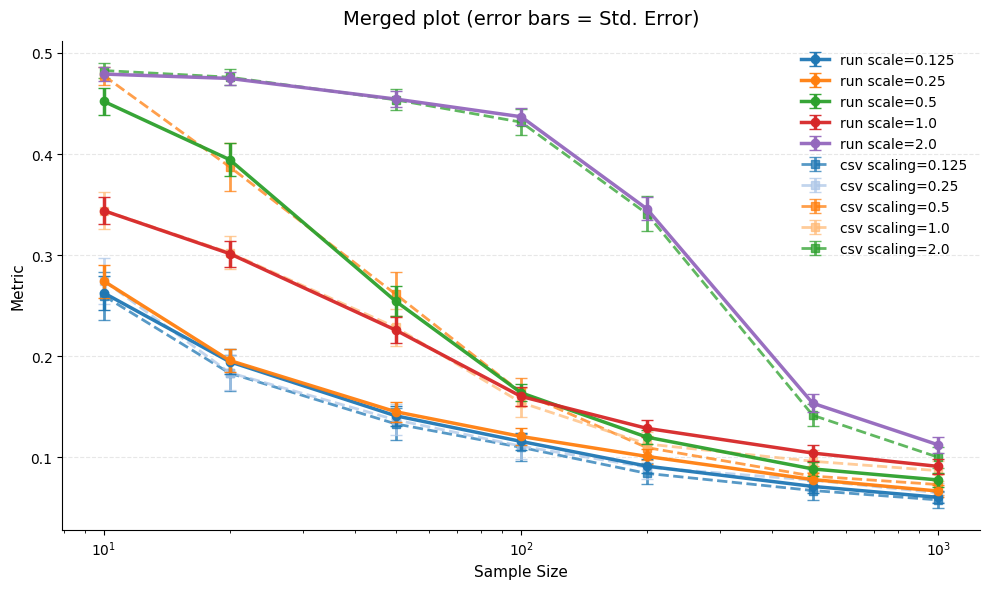

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _err_from_vals(vals, error_type="se"):
    vals = np.asarray(vals, dtype=float)
    mean = float(np.mean(vals))
    std = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
    err = std if error_type == "std" else std / np.sqrt(len(vals))
    return mean, err

def plot_merged_run_and_csv(
    run_data,
    csv_path,
    metric_name,          # key in run_data
    type_val,             # e.g. "train" or "valid" inside dict
    alphas,
    seeds,
    samples,
    csv_metric="valid",   # column in CSV to plot
    csv_mode=None,        # "finetuning" / "multitask" / None
    group_col="scaling",  # grouping column in CSV (like alpha)
    log_x=True,
    use_one_minus_acc=True,
    error_type="se",      # "std" or "se"
):
    assert error_type in {"std", "se"}

    fig, ax = plt.subplots(figsize=(10, 6))

    # separate color palettes to make both sources visible
    run_cmap = plt.colormaps["tab10"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab10")
    csv_cmap = plt.colormaps["tab20"] if hasattr(plt, "colormaps") else plt.cm.get_cmap("tab20")

    # --------- RUN_DATA PLOT (alpha curves) ----------
    metric_lower = str(metric_name).lower()
    do_one_minus_run = use_one_minus_acc and ("acc" in metric_lower or "accuracy" in metric_lower)

    for i, alpha in enumerate(alphas):
        means, errs = [], []

        for sample in samples:
            vals = []
            for seed in seeds:
                try:
                    data_matrix = run_data[metric_name][alpha][sample]
                    v = data_matrix[seed]
                    data_dict = v.item() if hasattr(v, "item") else v

                    y = np.max(data_dict[type_val])
                    if do_one_minus_run:
                        y = 1.0 - y
                    vals.append(y)
                except (KeyError, IndexError, TypeError, ValueError):
                    continue

            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        # If everything is NaN, nothing will appear
        if np.all(np.isnan(means)):
            print(f"[WARN] run_data: α={alpha} produced all-NaN (likely key mismatch / missing data). Skipping.")
            continue

        ax.errorbar(
            samples, means, yerr=errs,
            label=f"run scale={alpha}",
            color=run_cmap(i % 10),
            linestyle="-",
            marker="o",
            linewidth=2.5,
            capsize=4,
            alpha=0.95,
            zorder=3,  # on top
        )

    # --------- CSV PLOT (scaling curves) ----------
    df = pd.read_csv(csv_path)

    # numeric coercion (blank cells -> NaN)
    for c in [csv_metric, group_col, "n_samples"]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if csv_mode is not None and "mode" in df.columns:
        df = df[df["mode"] == csv_mode]

    df = df.dropna(subset=[csv_metric, "n_samples"])

    mlow = str(csv_metric).lower()
    do_one_minus_csv = use_one_minus_acc and (
        "acc" in mlow or "accuracy" in mlow or csv_metric in {"train", "valid"}
    )

    groups = sorted(df[group_col].dropna().unique().tolist())
    x_vals = sorted(df["n_samples"].dropna().unique().tolist())

    for j, g in enumerate(groups):
        means, errs = [], []
        dfg = df[df[group_col] == g]

        for x in x_vals:
            vals = dfg[dfg["n_samples"] == x][csv_metric].dropna().to_numpy()
            if len(vals) == 0:
                means.append(np.nan)
                errs.append(np.nan)
            else:
                if do_one_minus_csv:
                    vals = 1.0 - vals
                m, e = _err_from_vals(vals, error_type=error_type)
                means.append(m)
                errs.append(e)

        if np.all(np.isnan(means)):
            print(f"[WARN] csv: {group_col}={g} produced all-NaN. Skipping.")
            continue

        ax.errorbar(
            x_vals, means, yerr=errs,
            label=f"csv {group_col}={g}",
            color=csv_cmap(j % 20),
            linestyle="--",
            marker="s",
            linewidth=2,
            capsize=4,
            alpha=0.75,
            zorder=2,
        )

    # --------- Styling ----------
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    if log_x:
        ax.set_xscale("log")

    errlab = "Std. Error" if error_type == "se" else "Std. Dev."
    ax.set_title(f"Merged plot (error bars = {errlab})", fontsize=14, pad=12)
    ax.set_xlabel("Sample Size", fontsize=11)
    ax.set_ylabel("Metric", fontsize=11)

    ax.legend(frameon=False, loc="best")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)
    plt.tight_layout()
    plt.show()


In [32]:
import torch
import numpy as np
from pathlib import Path
seeds = list(range(20))
alphas = [0.01,0.1,0.5,1.0,2,5]
 #/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_3/
n_samples=[10, 20, 50, 100, 200, 500, 1000]
#random_seed=0--mode=finetuning--n_samples=10--alpha=1.0--alpha_policy=first_vs_rest--model=resnet
base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/extentions_all")
 #base_path = Path("/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/main_3/")
run_data = {
    'losses': {a:{s: [] for s in n_samples} for a in alphas},
    'accs': {a: {s: [] for s in n_samples} for a in alphas},
    'models': {a: {s: [] for s in n_samples} for a in alphas},
    'l2_regs': {a: {s: [] for s in n_samples} for a in alphas}
}
for alpha in alphas:
    for seed in seeds:
        for n_sample in n_samples :
            folder_name = (
                f"random_seed={seed}--mode=finetuning--alpha_load={alpha}--n_samples={n_sample}"
            )
            dir_path = base_path / folder_name
            if dir_path.exists():
                print(f" {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
                # Load and append data to the lists
                if (dir_path / "losses.npy").exists():
                    run_data['losses'][alpha][n_sample].append(np.load(dir_path / "losses.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Losses")
                if (dir_path / "l2_regs.npy").exists():
                    run_data['l2_regs'][alpha][n_sample].append(np.load(dir_path / "l2_regs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, l2_regs")
                if (dir_path / "accs.npy").exists():
                    run_data['accs'][alpha][n_sample].append(np.load(dir_path / "accs.npy",allow_pickle=True))
                    print(f"✅ Loaded Seed {seed}, Alpha {alpha}, Sample {n_sample}, Accs"),
            else:
                print(f"Missing directory: {folder_name}")

 0, Alpha 0.01, Sample 10, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 10, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 10, Accs
 0, Alpha 0.01, Sample 20, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 20, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 20, Accs
 0, Alpha 0.01, Sample 50, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 50, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 50, Accs
 0, Alpha 0.01, Sample 100, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 100, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 100, Accs
 0, Alpha 0.01, Sample 200, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 200, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 200, Accs
 0, Alpha 0.01, Sample 500, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 500, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 500, Accs
 0, Alpha 0.01, Sample 1000, Accs
✅ Loaded Seed 0, Alpha 0.01, Sample 1000, Losses
✅ Loaded Seed 0, Alpha 0.01, Sample 1000, Accs
 1, Alpha 0.01, Sample 10, Accs
✅ Loaded Seed 1, Alpha 0.01, Sample 10, Losses
✅ Loaded Seed 1, Alpha 0.01, Sample 10

✅ Loaded Seed 17, Alpha 0.01, Sample 200, Accs
 17, Alpha 0.01, Sample 500, Accs
✅ Loaded Seed 17, Alpha 0.01, Sample 500, Losses
✅ Loaded Seed 17, Alpha 0.01, Sample 500, Accs
 17, Alpha 0.01, Sample 1000, Accs
✅ Loaded Seed 17, Alpha 0.01, Sample 1000, Losses
✅ Loaded Seed 17, Alpha 0.01, Sample 1000, Accs
 18, Alpha 0.01, Sample 10, Accs
✅ Loaded Seed 18, Alpha 0.01, Sample 10, Losses
✅ Loaded Seed 18, Alpha 0.01, Sample 10, Accs
 18, Alpha 0.01, Sample 20, Accs
✅ Loaded Seed 18, Alpha 0.01, Sample 20, Losses
✅ Loaded Seed 18, Alpha 0.01, Sample 20, Accs
 18, Alpha 0.01, Sample 50, Accs
✅ Loaded Seed 18, Alpha 0.01, Sample 50, Losses
✅ Loaded Seed 18, Alpha 0.01, Sample 50, Accs
 18, Alpha 0.01, Sample 100, Accs
✅ Loaded Seed 18, Alpha 0.01, Sample 100, Losses
✅ Loaded Seed 18, Alpha 0.01, Sample 100, Accs
 18, Alpha 0.01, Sample 200, Accs
✅ Loaded Seed 18, Alpha 0.01, Sample 200, Losses
✅ Loaded Seed 18, Alpha 0.01, Sample 200, Accs
 18, Alpha 0.01, Sample 500, Accs
✅ Loaded Seed 1

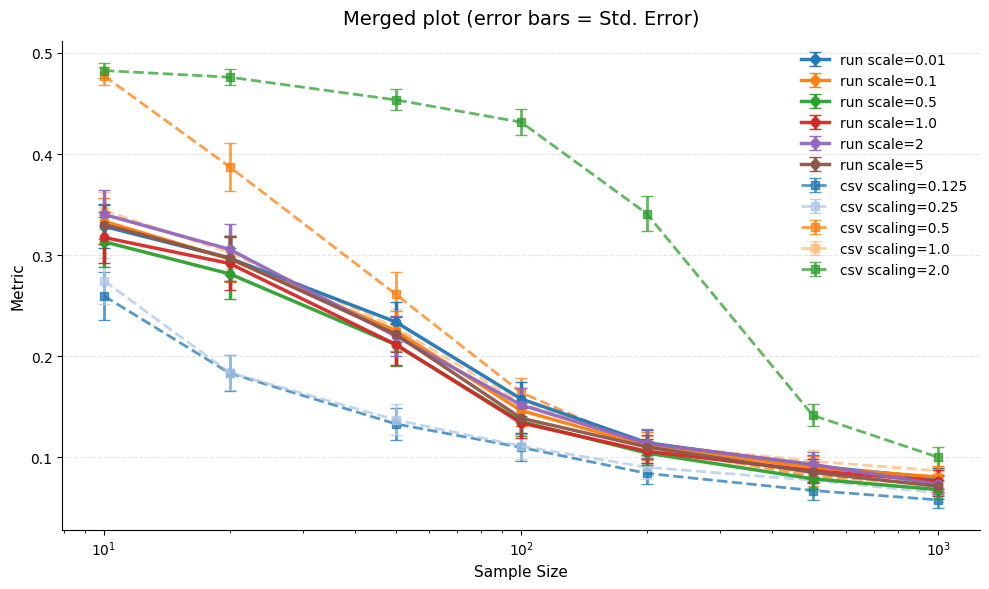

In [33]:
plot_merged_run_and_csv(
    run_data=run_data,
    #csv_path="/nfs/nhome/live/cdomine/nested_feature/experiments/cifar/data/cifar/resnet_acc_max.csv",
    csv_path="/nfs/gatsbystor/cdomine/cifar_testing/cifar/resnet_acc_max_main_samscale_sam.csv",
    metric_name="accs",
    type_val="valid",
    alphas = [0.01,0.1,0.5,1.0,2,5],
    seeds=list(range(50)),
    samples=[10, 20, 50, 100, 200, 500, 1000],
    csv_metric="valid",
    csv_mode="finetuning",
    error_type="se")

In [ ]:
# This is concatenated with the maximal validation error, we can also run it with the error at the end.
import os
import pandas as pd
import numpy as np
import plotnine as gg
import torch
import numpy as np
from pathlib import Path

base_path = Path("/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/")

df = []
for folder in os.listdir('/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/'):
    if 'accs.npy' in os.listdir(f'/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/{folder}') and\
    (folder.split('--')[1].split('=')[1] != 'finetuning' or len(folder.split('--'))==5):
        new_df = pd.DataFrame({
            k: [v.max()] for k,v in np.load(f'/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/{folder}/accs.npy', allow_pickle=True)[()].items()\
            if len(v)!=0
            }
        )
        new_df['rs'] = folder.split('--')[0].split('=')[1]
        new_df['mode'] = folder.split('--')[1].split('=')[1]
        new_df['n_samples'] = int(folder.split('--')[2].split('=')[1])
        if folder.split('--')[1].split('=')[1] == 'finetuning':
            new_df['scaling'] = float(folder.split('--')[3].split('=')[1])
        df.append(new_df)
df = pd.concat(df)

df.to_csv('/nfs/gatsbystor/cdomine/cifar_testing/cifar/main_samscale_sam/resnet_acc_max.csv')

(gg.ggplot(df[(df['scaling']==1)|np.isnan(df['scaling'])], gg.aes('n_samples', '1-valid', color='mode')) +
 gg.stat_summary(geom='line') +
 gg.stat_summary(geom='linerange') +
 gg.scale_x_log10() +
 gg.scale_y_log10())
(gg.ggplot(df[df['mode']=='finetuning'], gg.aes('n_samples', '1-valid', color='scaling', group='scaling')) +
 gg.stat_summary(geom='line') +
 gg.stat_summary(geom='linerange') +
 gg.scale_x_log10())